In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [240]:
df = pd.read_csv("../Dataset/df_for_EDA.csv")

In [241]:
df = df.set_index("Datetime")

In [242]:
df.isna().sum().sum()

np.int64(0)

In [243]:
df = df[~df.index.duplicated(keep="first")]

In [244]:
df = df.sort_index()


In [245]:
print(df.index.min())
print(df.index.max())
print(df.shape)

1998-04-01 01:00:00
2015-01-01 00:00:00
(145197, 14)


In [246]:
print("Total rows:", len(df))
print("Duplicate indexes:", df.index.duplicated().sum())

Total rows: 145197
Duplicate indexes: 0


In [247]:
duplicates = df[df.index.duplicated(keep=False)]

print(duplicates)

Empty DataFrame
Columns: [PJME_MW, Hour, DayOfWeek, Month, Day, Week, Year, IsWeekend, Lag_1, Lag_24, Lag_168, RollingMean_24, RollingMean_168, RollingStd_24]
Index: []


In [248]:
df.isnull().sum()

PJME_MW            0
Hour               0
DayOfWeek          0
Month              0
Day                0
Week               0
Year               0
IsWeekend          0
Lag_1              0
Lag_24             0
Lag_168            0
RollingMean_24     0
RollingMean_168    0
RollingStd_24      0
dtype: int64

In [249]:
test_size = int(len(df) * 0.20)

test_df = df.iloc[-test_size:].copy()

remaining_df = df.iloc[:-test_size].copy()

validation_hours = 60 * 24

val_df = remaining_df.iloc[-validation_hours:].copy()

train_df = remaining_df.iloc[:-validation_hours].copy()

In [250]:
# train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)

In [251]:
train_df

,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
Datetime,,,,,,,,,,,,,,
1998-04-01 01:00:00,21734.0,1,2,4,1,14,1998,0,24853.0,24372.0,25356.0,28491.666667,28462.184524,3325.665055
1998-04-01 02:00:00,20971.0,2,2,4,1,14,1998,0,21734.0,23534.0,24055.0,28384.875000,28443.827381,3526.849602
1998-04-01 03:00:00,20721.0,3,2,4,1,14,1998,0,20971.0,23243.0,23206.0,28279.791667,28429.035714,3719.048779
1998-04-01 04:00:00,20771.0,4,2,4,1,14,1998,0,20721.0,23296.0,22926.0,28174.583333,28416.208333,3897.594408
1998-04-01 05:00:00,21334.0,5,2,4,1,14,1998,0,20771.0,23924.0,22929.0,28066.666667,28406.714286,4053.153294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-05-10 22:00:00,37372.0,22,1,5,10,19,2011,0,37400.0,38945.0,44932.0,31719.166667,33757.886905,5228.841028
2011-05-10 23:00:00,36706.0,23,1,5,10,19,2011,0,37372.0,38351.0,43940.0,31650.625000,33714.827381,5148.289913
2011-05-11 00:00:00,35474.0,0,2,5,11,19,2011,0,36706.0,37054.0,41872.0,31584.791667,33676.744048,5085.914761


In [252]:
test_df

,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
Datetime,,,,,,,,,,,,,,
2011-07-10 03:00:00,26969.0,3,6,7,10,27,2011,1,28993.0,24346.0,25811.0,27958.333333,26172.119048,4136.194372
2011-07-10 04:00:00,24807.0,4,6,7,10,27,2011,1,26969.0,22828.0,24016.0,28040.791667,26176.827381,4048.262032
2011-07-10 05:00:00,22524.0,5,6,7,10,27,2011,1,24807.0,22863.0,22412.0,28026.666667,26177.494048,4067.658558
2011-07-10 06:00:00,21542.0,6,6,7,10,27,2011,1,22524.0,21861.0,21510.0,28013.375000,26177.684524,4089.146172
2011-07-10 07:00:00,21042.0,7,6,7,10,27,2011,1,21542.0,21341.0,21016.0,28000.916667,26177.839286,4110.757012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 20:00:00,33503.0,20,2,12,31,1,2014,0,33217.0,28946.0,31403.0,28042.708333,27169.648810,2790.002813
2014-12-31 21:00:00,33443.0,21,2,12,31,1,2014,0,33503.0,28643.0,31130.0,28242.708333,27183.416667,2999.111904
2014-12-31 22:00:00,33243.0,22,2,12,31,1,2014,0,33443.0,28099.0,30668.0,28457.041667,27198.744048,3167.478732


In [253]:
train_df.isna().sum()

PJME_MW            0
Hour               0
DayOfWeek          0
Month              0
Day                0
Week               0
Year               0
IsWeekend          0
Lag_1              0
Lag_24             0
Lag_168            0
RollingMean_24     0
RollingMean_168    0
RollingStd_24      0
dtype: int64

In [254]:
y_train = train_df["PJME_MW"]
y_test = test_df["PJME_MW"]

In [255]:
y_train

Datetime
1998-04-01 01:00:00    21734.0
1998-04-01 02:00:00    20971.0
1998-04-01 03:00:00    20721.0
1998-04-01 04:00:00    20771.0
1998-04-01 05:00:00    21334.0
                        ...   
2011-05-10 22:00:00    37372.0
2011-05-10 23:00:00    36706.0
2011-05-11 00:00:00    35474.0
2011-05-11 01:00:00    36983.0
2011-05-11 02:00:00    35859.0
Name: PJME_MW, Length: 114718, dtype: float64

In [256]:
y_test

Datetime
2011-07-10 03:00:00    26969.0
2011-07-10 04:00:00    24807.0
2011-07-10 05:00:00    22524.0
2011-07-10 06:00:00    21542.0
2011-07-10 07:00:00    21042.0
                        ...   
2014-12-31 20:00:00    33503.0
2014-12-31 21:00:00    33443.0
2014-12-31 22:00:00    33243.0
2014-12-31 23:00:00    33059.0
2015-01-01 00:00:00    32664.0
Name: PJME_MW, Length: 29039, dtype: float64

In [257]:
y_test.isna().sum()

np.int64(0)

In [258]:
y_train.isna().sum()

np.int64(0)

In [259]:
y_train.duplicated().sum()

np.int64(87486)

In [260]:
y_test.duplicated().sum()

np.int64(12783)

In [261]:
y_train.iloc[-1]

np.float64(35859.0)

In [262]:
# Naive forecast

naive_forecast = pd.Series(
    y_train.iloc[-1],
    index=y_test.index
)

naive_forecast

Datetime
2011-07-10 03:00:00    35859.0
2011-07-10 04:00:00    35859.0
2011-07-10 05:00:00    35859.0
2011-07-10 06:00:00    35859.0
2011-07-10 07:00:00    35859.0
                        ...   
2014-12-31 20:00:00    35859.0
2014-12-31 21:00:00    35859.0
2014-12-31 22:00:00    35859.0
2014-12-31 23:00:00    35859.0
2015-01-01 00:00:00    35859.0
Length: 29039, dtype: float64

In [263]:
naive_forecast.isna().sum()

np.int64(0)

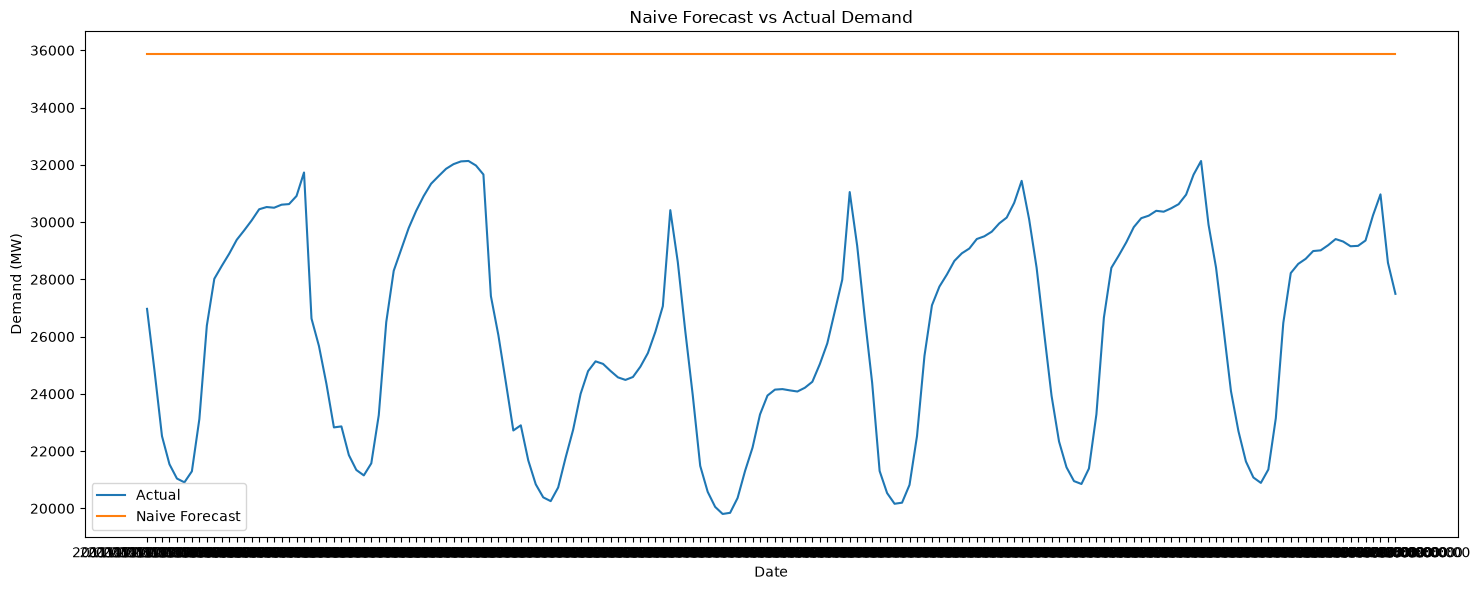

In [264]:
plot_days = 7

actual_plot = y_test.iloc[:24 * plot_days]
naive_plot = naive_forecast.iloc[:24 * plot_days]

plt.figure(figsize=(15, 6))

plt.plot(
    actual_plot.index,
    actual_plot.values,
    label="Actual"
)

plt.plot(
    naive_plot.index,
    naive_plot.values,
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()

plt.tight_layout()
plt.show()

In [265]:
y_test.index

Index(['2011-07-10 03:00:00', '2011-07-10 04:00:00', '2011-07-10 05:00:00',
       '2011-07-10 06:00:00', '2011-07-10 07:00:00', '2011-07-10 08:00:00',
       '2011-07-10 09:00:00', '2011-07-10 10:00:00', '2011-07-10 11:00:00',
       '2011-07-10 12:00:00',
       ...
       '2014-12-31 15:00:00', '2014-12-31 16:00:00', '2014-12-31 17:00:00',
       '2014-12-31 18:00:00', '2014-12-31 19:00:00', '2014-12-31 20:00:00',
       '2014-12-31 21:00:00', '2014-12-31 22:00:00', '2014-12-31 23:00:00',
       '2015-01-01 00:00:00'],
      dtype='str', name='Datetime', length=29039)

In [266]:
# Moving Average

window = 24
moving_average_forecast = pd.Series(
    y_train.iloc[-window:].mean(),
    index=y_test.index
)

moving_average_forecast

Datetime
2011-07-10 03:00:00    31587.958333
2011-07-10 04:00:00    31587.958333
2011-07-10 05:00:00    31587.958333
2011-07-10 06:00:00    31587.958333
2011-07-10 07:00:00    31587.958333
                           ...     
2014-12-31 20:00:00    31587.958333
2014-12-31 21:00:00    31587.958333
2014-12-31 22:00:00    31587.958333
2014-12-31 23:00:00    31587.958333
2015-01-01 00:00:00    31587.958333
Length: 29039, dtype: float64

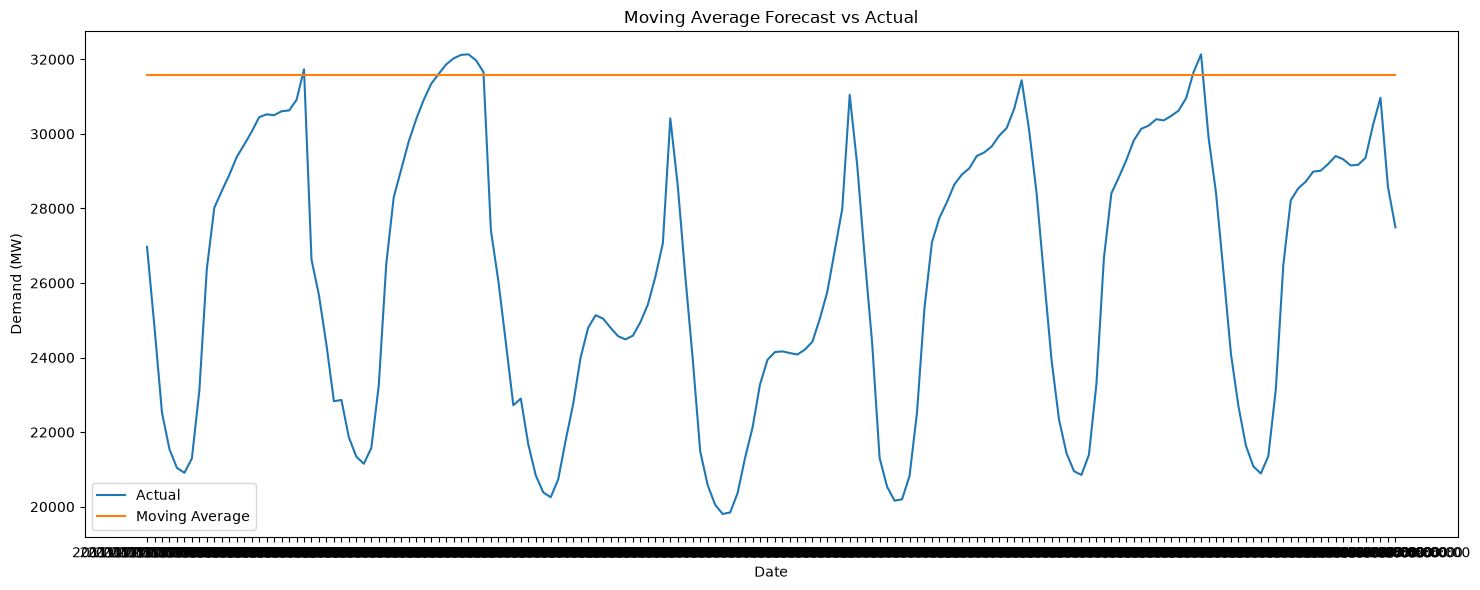

In [267]:
ma_plot = moving_average_forecast.iloc[:24 * plot_days]

plt.figure(figsize=(15, 6))

plt.plot(
    actual_plot.index,
    actual_plot.values,
    label="Actual"
)

plt.plot(
    ma_plot.index,
    ma_plot.values,
    label="Moving Average"
)

plt.title("Moving Average Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()

plt.tight_layout()
plt.show()

In [268]:
moving_average_forecast.isna().sum()

np.int64(0)

In [269]:
y_test.duplicated().sum()

np.int64(12783)

In [270]:
previous_day_forecast = df["PJME_MW"].shift(24)

previous_day_forecast = previous_day_forecast.reindex(y_test.index)

In [271]:
previous_day_forecast.isna().sum()

np.int64(0)

In [272]:
previous_day_forecast = previous_day_forecast.fillna(previous_day_forecast.median())

In [273]:
previous_day_forecast.isna().sum()

np.int64(0)

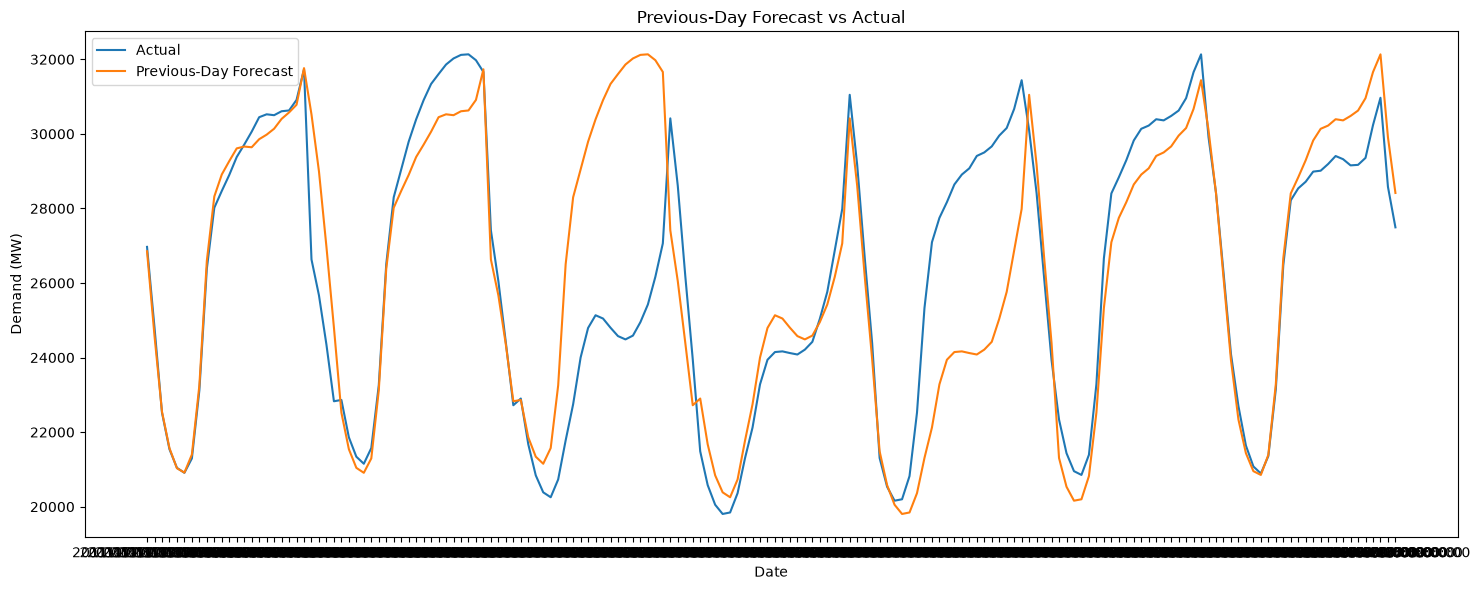

In [274]:
previous_day_plot = previous_day_forecast.iloc[:24 * plot_days]

plt.figure(figsize=(15, 6))

plt.plot(
    actual_plot.index,
    actual_plot.values,
    label="Actual"
)

plt.plot(
    previous_day_plot.index,
    previous_day_plot.values,
    label="Previous-Day Forecast"
)

plt.title("Previous-Day Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()

plt.tight_layout()
plt.show()

In [275]:
# previous_week_forecast

previous_week_forecast = df["PJME_MW"].shift(168)

previous_week_forecast = previous_week_forecast.loc[
    y_test.index
]

previous_week_forecast

Datetime
2011-07-10 03:00:00    26297.0
2011-07-10 04:00:00    24480.0
2011-07-10 05:00:00    24141.0
2011-07-10 06:00:00    22898.0
2011-07-10 07:00:00    22134.0
                        ...   
2014-12-31 20:00:00    33600.0
2014-12-31 21:00:00    33417.0
2014-12-31 22:00:00    32308.0
2014-12-31 23:00:00    31207.0
2015-01-01 00:00:00    30093.0
Name: PJME_MW, Length: 29039, dtype: float64

In [276]:
previous_week_forecast.isna().sum()

np.int64(0)

In [277]:
previous_week_forecast.median()

np.float64(30532.0)

In [278]:
previous_week_forecast = previous_week_forecast.fillna(previous_week_forecast.median())

In [279]:
previous_week_forecast.isnull().sum()

np.int64(0)

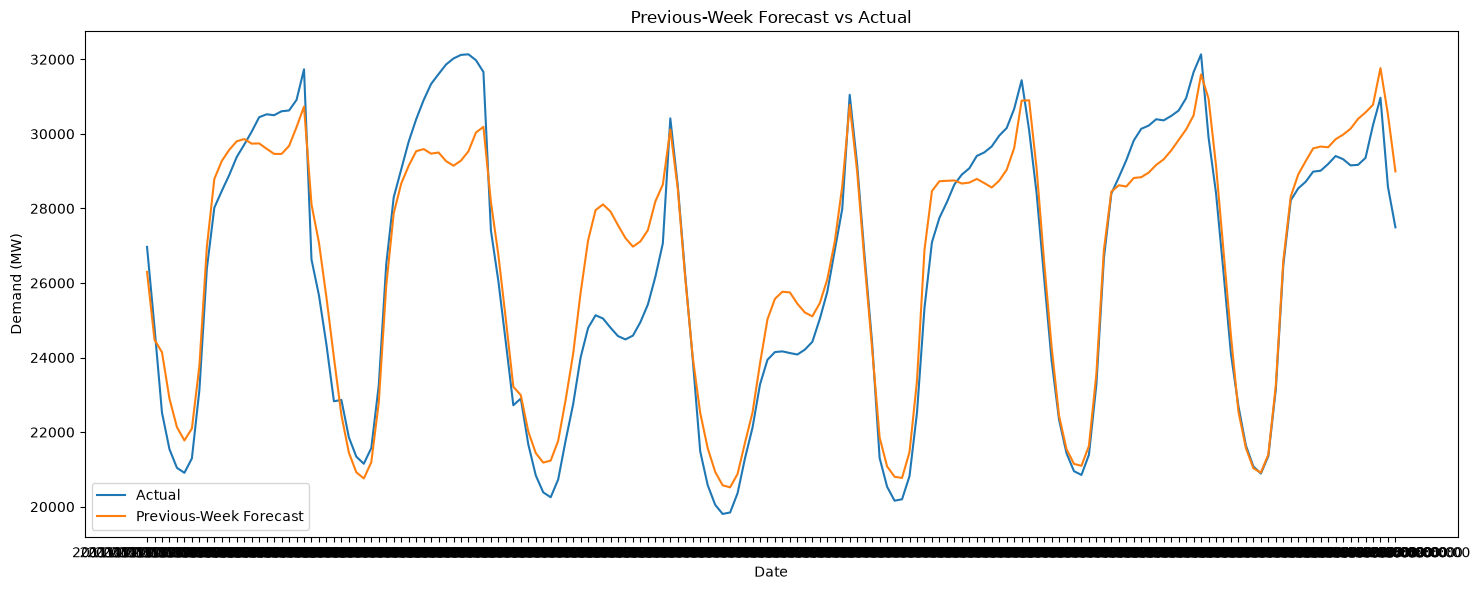

In [280]:
previous_week_plot = previous_week_forecast.iloc[:24 * plot_days]

plt.figure(figsize=(15, 6))

plt.plot(
    actual_plot.index,
    actual_plot.values,
    label="Actual"
)

plt.plot(
    previous_week_plot.index,
    previous_week_plot.values,
    label="Previous-Week Forecast"
)

plt.title("Previous-Week Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()

plt.tight_layout()
plt.show()

In [281]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [282]:
def evaluate_forecast(actual, forecast):

    mae = mean_absolute_error( actual, forecast ) 

    mse = mean_squared_error( actual, forecast )

    rmse = np.sqrt(mse)

    mape = mean_absolute_percentage_error( actual, forecast ) * 100

    r2 = r2_score( actual, forecast )

    bias = np.mean( forecast - actual )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Bias": bias
    }

In [283]:
print("y_test:", len(y_test))
print("previous_day_forecast:", len(previous_day_forecast))

y_test: 29039
previous_day_forecast: 29039


In [284]:
results = {}

results["Naive"] = evaluate_forecast(
    y_test,
    naive_forecast
)

results["Moving Average"] = evaluate_forecast(
    y_test,
    moving_average_forecast
)

results["Previous-Day"] = evaluate_forecast(
    y_test,
    previous_day_forecast
)

results["Previous-Week"] = evaluate_forecast(
    y_test,
    previous_week_forecast
)

In [285]:
results

{'Naive': {'MAE': 6495.306449946624,
  'MSE': 58339708.32149868,
  'RMSE': np.float64(7638.043487798343),
  'MAPE': 23.153187687372224,
  'R2': -0.497237046229412,
  'Bias': np.float64(4401.681187368711)},
 'Moving Average': {'MAE': 4922.991949045536,
  'MSE': 38981977.730632305,
  'RMSE': np.float64(6243.554895300617),
  'MAPE': 16.115202424330842,
  'R2': -0.0004380013686928752,
  'Bias': np.float64(130.63952070204226)},
 'Previous-Day': {'MAE': 2262.8796101794137,
  'MSE': 9715178.84868625,
  'RMSE': np.float64(3116.9181652212574),
  'MAPE': 7.115165359699247,
  'R2': 0.7506685223238052,
  'Bias': np.float64(-1.2752160887082888)},
 'Previous-Week': {'MAE': 3527.1219738971727,
  'MSE': 23815114.85488481,
  'RMSE': np.float64(4880.07324277872),
  'MAPE': 10.912301194045435,
  'R2': 0.388806127990152,
  'Bias': np.float64(-8.310513447432763)}}

In [286]:
baseline_results = pd.DataFrame(results).T

baseline_results

,MAE,MSE,RMSE,MAPE,R2,Bias
Naive,6495.306450,5.833971e+07,7638.043488,23.153188,-0.497237,4401.681187
Moving Average,4922.991949,3.898198e+07,6243.554895,16.115202,-0.000438,130.639521
Previous-Day,2262.879610,9.715179e+06,3116.918165,7.115165,0.750669,-1.275216
Previous-Week,3527.121974,2.381511e+07,4880.073243,10.912301,0.388806,-8.310513


In [ ]:
test_df = test_df.copy()
 
# Naive Forecast (Lag 1)
test_df['pred_naive'] = test_df['PJME_MW'].shift(1)
 
# Previous-Day Forecast (Lag 24)
test_df['pred_prev_day'] = test_df['PJME_MW'].shift(24)
 
# Previous-Week Forecast (Lag 168)
test_df['pred_prev_week'] = test_df['PJME_MW'].shift(168)
 
# Moving Average Forecast (24-Hour Rolling Mean)
test_df['pred_moving_avg'] = test_df['PJME_MW'].shift(1).rolling(window=24).mean()
 
# Drop initial NaNs generated by shifting to ensure aligned evaluation
eval_df = test_df.dropna().copy()
 
# 2. Define Evaluation Metrics Function
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2
 
# 3. Calculate Performance Metrics
baselines = {
    'Naive (Lag 1)': eval_df['pred_naive'],
    'Previous-Day (Lag 24)': eval_df['pred_prev_day'],
    'Previous-Week (Lag 168)': eval_df['pred_prev_week'],
    '24-Hour Moving Average': eval_df['pred_moving_avg']
}
 
results = []
for name, preds in baselines.items():
    mae, rmse, mape, r2 = evaluate_forecast(eval_df['PJME_MW'], preds)
    results.append({
        'Model': name,
        'MAE (MW)': round(mae, 2),
        'RMSE (MW)': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'R²': round(r2, 2)
    })
 
# Display Results Table
baseline_summary = pd.DataFrame(results).sort_values(by='RMSE (MW)')
print(baseline_summary)

                     Model  MAE (MW)  RMSE (MW)  MAPE (%)    R²
0            Naive (Lag 1)   1207.86    1808.41      3.86  0.92
1    Previous-Day (Lag 24)   2267.30    3120.65      7.12  0.75
3   24-Hour Moving Average   3501.35    4456.37     11.44  0.49
2  Previous-Week (Lag 168)   3542.48    4893.50     10.96  0.39
